In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

In [2]:
PATH = 'slooze_challenge./'

purchases = pd.read_csv(PATH + 'PurchasesFINAL12312016.csv')
invoices  = pd.read_csv(PATH + 'InvoicePurchases12312016.csv')
abc       = pd.read_csv(PATH + 'abc_classified_products.csv')

for col in ['PODate','ReceivingDate','InvoiceDate','PayDate']:
    purchases[col] = pd.to_datetime(purchases[col])

for col in ['PODate','InvoiceDate','PayDate']:
    invoices[col] = pd.to_datetime(invoices[col])

for df in [purchases, invoices]:
    str_cols = df.select_dtypes('object').columns
    df[str_cols] = df[str_cols].apply(lambda c: c.str.strip())

print('loaded. purchases shape:', purchases.shape)

loaded. purchases shape: (2372474, 16)


In [3]:
purchases['lead_days']          = (purchases['ReceivingDate'] - purchases['PODate']).dt.days
purchases['invoice_to_pay_days'] = (purchases['PayDate'] - purchases['InvoiceDate']).dt.days
purchases['po_to_invoice_days']  = (purchases['InvoiceDate'] - purchases['PODate']).dt.days

clean = purchases[(purchases['lead_days'] >= 0) & (purchases['lead_days'] <= 365)].copy()
removed = len(purchases) - len(clean)
print(f'Removed {removed} rows with invalid lead times ({removed/len(purchases)*100:.2f}%)')

print(f"\nLead time stats (days):")
print(clean['lead_days'].describe().round(1))

Removed 0 rows with invalid lead times (0.00%)

Lead time stats (days):
count    2372474.0
mean           7.6
std            2.2
min            3.0
25%            6.0
50%            8.0
75%            9.0
max           14.0
Name: lead_days, dtype: float64


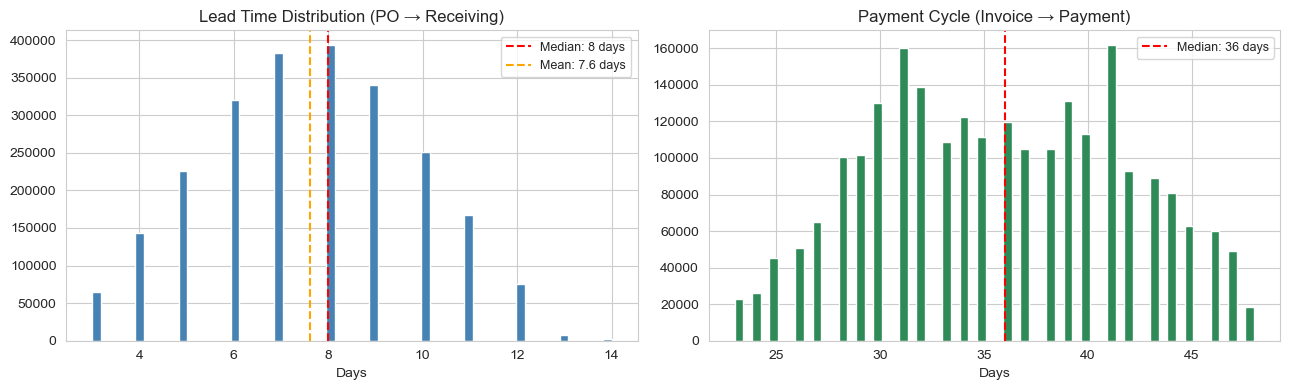

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(clean['lead_days'].clip(0, 60), bins=60, color='steelblue', edgecolor='white')
axes[0].axvline(clean['lead_days'].median(), color='red', linestyle='--',
                label=f"Median: {clean['lead_days'].median():.0f} days")
axes[0].axvline(clean['lead_days'].mean(), color='orange', linestyle='--',
                label=f"Mean: {clean['lead_days'].mean():.1f} days")
axes[0].set_title('Lead Time Distribution (PO → Receiving)')
axes[0].set_xlabel('Days')
axes[0].legend(fontsize=9)

pay_clean = clean[(clean['invoice_to_pay_days'] >= 0) & (clean['invoice_to_pay_days'] <= 180)]
axes[1].hist(pay_clean['invoice_to_pay_days'], bins=60, color='seagreen', edgecolor='white')
axes[1].axvline(pay_clean['invoice_to_pay_days'].median(), color='red', linestyle='--',
                label=f"Median: {pay_clean['invoice_to_pay_days'].median():.0f} days")
axes[1].set_title('Payment Cycle (Invoice → Payment)')
axes[1].set_xlabel('Days')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig('plot_lead_time_dist.png', dpi=150, bbox_inches='tight')
plt.show()

In [7]:
vendor_lt = (
    clean.groupby('VendorName')
    .agg(
        avg_lead_days   = ('lead_days', 'mean'),
        median_lead_days= ('lead_days', 'median'),
        std_lead_days   = ('lead_days', 'std'),
        total_orders    = ('PONumber',  'nunique'),
        total_spend     = ('Dollars',   'sum')
    )
    .reset_index()
    .query('total_orders >= 5')
    .sort_values('avg_lead_days')
)

vendor_lt['cv'] = vendor_lt['std_lead_days'] / vendor_lt['avg_lead_days'] 

print(f'{len(vendor_lt)} vendors with >= 5 orders')

print('\nTop 10 fastest vendors (avg lead days):')
print(vendor_lt.head(10)[['VendorName','avg_lead_days','std_lead_days','total_orders']].to_string(index=False))

print('\nTop 10 slowest vendors:')
print(vendor_lt.tail(10)[['VendorName','avg_lead_days','std_lead_days','total_orders']].to_string(index=False))

118 vendors with >= 5 orders

Top 10 fastest vendors (avg lead days):
                 VendorName  avg_lead_days  std_lead_days  total_orders
HIGHLAND WINE MERCHANTS LLC       5.321429       2.178235             7
       ALISA CARR BEVERAGES       6.809524       2.723003            19
                Circa Wines       6.948498       1.977658            43
      PHILLIPS PRODUCTS CO.       7.012447       2.109132            55
    SEA HAGG DISTILLERY LLC       7.022823       2.038210            54
                NICHE W & S       7.069797       2.350258            55
          MOONLIGHT MEADERY       7.083700       2.478208            54
          Serralles Usa LLC       7.117296       2.129158            54
             WEIN BAUER INC       7.126866       2.022646            53
   TRINCHERO FAMILY ESTATES       7.129843       2.276994            55

Top 10 slowest vendors:
                VendorName  avg_lead_days  std_lead_days  total_orders
    THE PIERPONT GROUP LLC       8.241935 

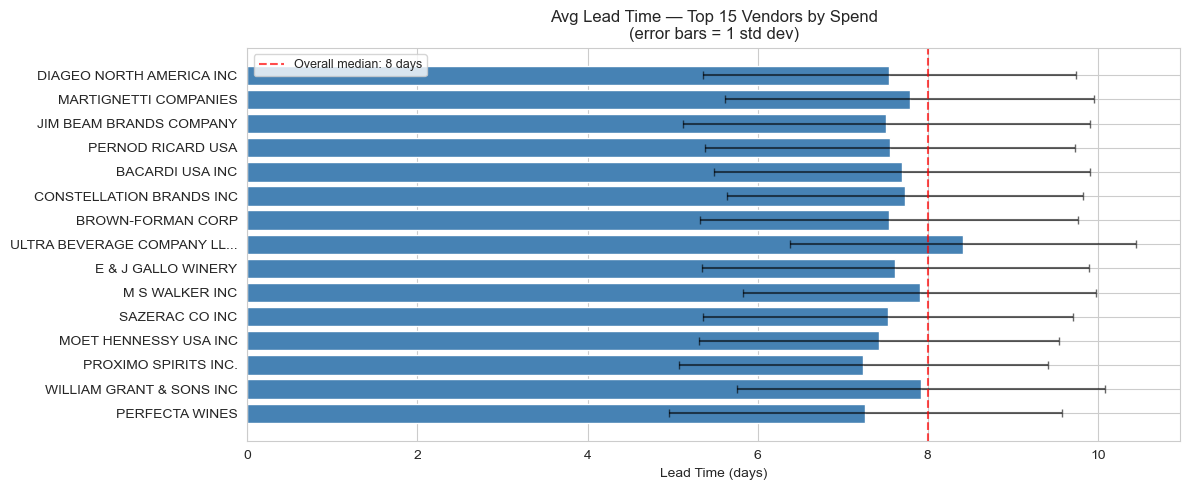

In [8]:
top_spend_vendors = vendor_lt.nlargest(15, 'total_spend')

fig, ax = plt.subplots(figsize=(12, 5))
names = [n[:25] + '...' if len(n) > 25 else n for n in top_spend_vendors['VendorName']]

bars = ax.barh(names[::-1], top_spend_vendors['avg_lead_days'].values[::-1], color='steelblue')
ax.errorbar(
    top_spend_vendors['avg_lead_days'].values[::-1],
    np.arange(len(names)),
    xerr=top_spend_vendors['std_lead_days'].values[::-1],
    fmt='none', color='black', capsize=3, alpha=0.6
)

ax.axvline(clean['lead_days'].median(), color='red', linestyle='--', alpha=0.7,
           label=f"Overall median: {clean['lead_days'].median():.0f} days")
ax.set_title('Avg Lead Time — Top 15 Vendors by Spend\n(error bars = 1 std dev)')
ax.set_xlabel('Lead Time (days)')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('plot_vendor_lead_times.png', dpi=150, bbox_inches='tight')
plt.show()

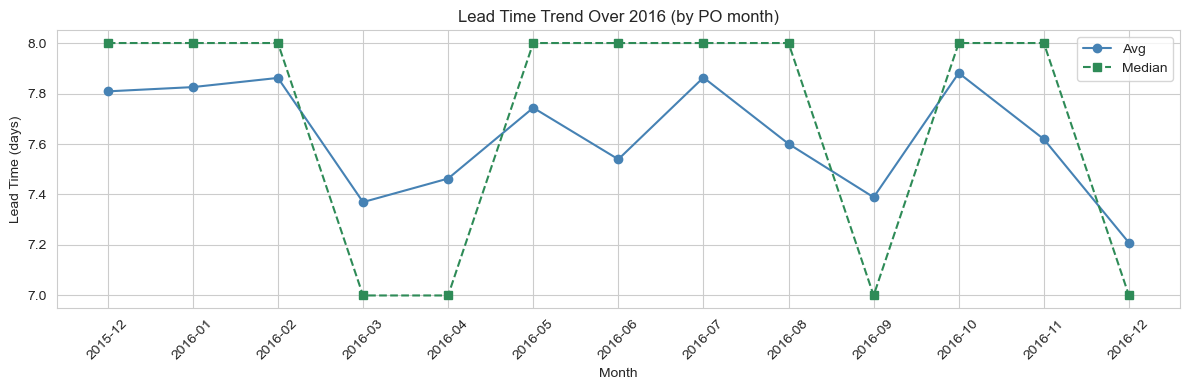

In [10]:
clean['po_month'] = clean['PODate'].dt.to_period('M')

monthly_lt = (
    clean.groupby('po_month')
    .agg(avg_lead=('lead_days','mean'),
         median_lead=('lead_days','median'),
         n_orders=('PONumber','nunique'))
    .reset_index()
)
monthly_lt['po_month'] = monthly_lt['po_month'].astype(str)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(monthly_lt['po_month'], monthly_lt['avg_lead'], marker='o', color='steelblue', label='Avg')
ax.plot(monthly_lt['po_month'], monthly_lt['median_lead'], marker='s', color='seagreen',
        linestyle='--', label='Median')
ax.set_title('Lead Time Trend Over 2016 (by PO month)')
ax.set_ylabel('Lead Time (days)')
ax.set_xlabel('Month')
ax.tick_params(axis='x', rotation=45)
ax.legend()
plt.tight_layout()
plt.savefig('plot_lead_time_trend.png', dpi=150, bbox_inches='tight')
plt.show()

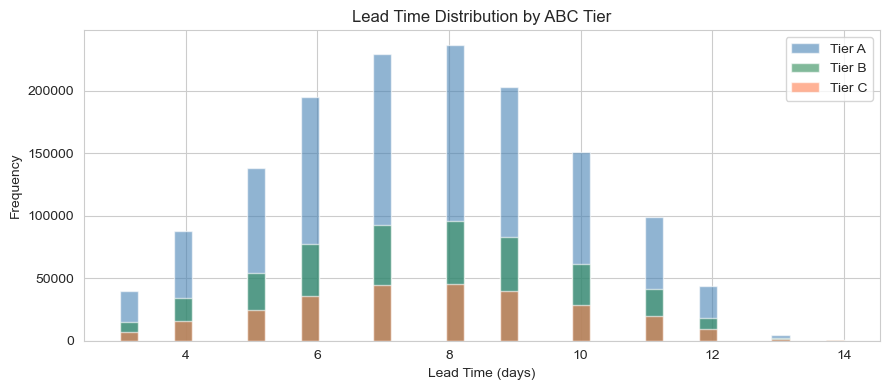

Lead time stats by ABC tier:
         count  mean  std  min  25%  50%  75%   max
ABC                                                
A    1429874.0   7.6  2.2  3.0  6.0  8.0  9.0  14.0
B     576459.0   7.6  2.2  3.0  6.0  8.0  9.0  14.0
C     271563.0   7.7  2.2  3.0  6.0  8.0  9.0  14.0


In [11]:
clean_abc = clean.merge(abc[['Brand','ABC']], on='Brand', how='left')

fig, ax = plt.subplots(figsize=(9, 4))

for tier, color in zip(['A','B','C'], ['steelblue','seagreen','coral']):
    data = clean_abc[clean_abc['ABC'] == tier]['lead_days'].clip(0, 60)
    ax.hist(data, bins=40, alpha=0.6, color=color, label=f'Tier {tier}', edgecolor='white')

ax.set_title('Lead Time Distribution by ABC Tier')
ax.set_xlabel('Lead Time (days)')
ax.set_ylabel('Frequency')
ax.legend()
plt.tight_layout()
plt.savefig('plot_lead_time_by_abc.png', dpi=150, bbox_inches='tight')
plt.show()

print('Lead time stats by ABC tier:')
print(clean_abc.groupby('ABC')['lead_days'].describe().round(1))

Vendors with high variability AND significant spend: 0
Empty DataFrame
Columns: [VendorName, avg_lead_days, std_lead_days, cv, total_orders, total_spend]
Index: []


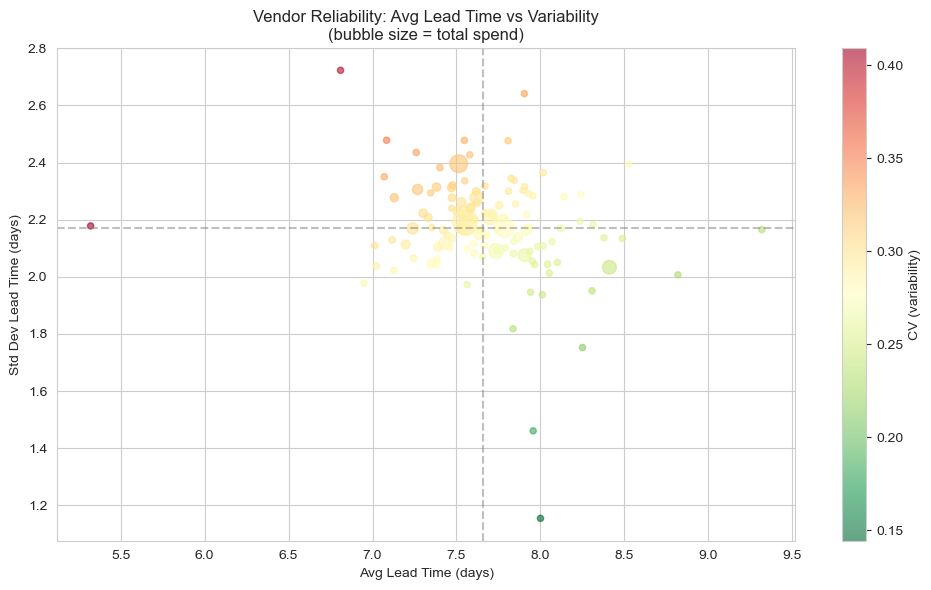

In [12]:
risky_vendors = vendor_lt[
    (vendor_lt['cv'] > 0.5) & (vendor_lt['total_spend'] > vendor_lt['total_spend'].quantile(0.5))
].sort_values('total_spend', ascending=False)

print(f'Vendors with high variability AND significant spend: {len(risky_vendors)}')
print(risky_vendors[['VendorName','avg_lead_days','std_lead_days','cv','total_orders','total_spend']]
      .head(10).to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 6))
sc = ax.scatter(
    vendor_lt['avg_lead_days'],
    vendor_lt['std_lead_days'],
    s=vendor_lt['total_spend'] / vendor_lt['total_spend'].max() * 300 + 20,
    alpha=0.6, c=vendor_lt['cv'], cmap='RdYlGn_r'
)
plt.colorbar(sc, label='CV (variability)')
ax.set_xlabel('Avg Lead Time (days)')
ax.set_ylabel('Std Dev Lead Time (days)')
ax.set_title('Vendor Reliability: Avg Lead Time vs Variability\n(bubble size = total spend)')

ax.axvline(vendor_lt['avg_lead_days'].median(), color='grey', linestyle='--', alpha=0.5)
ax.axhline(vendor_lt['std_lead_days'].median(), color='grey', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('plot_vendor_reliability.png', dpi=150, bbox_inches='tight')
plt.show()